In [1]:
import pandas as pd

In [14]:
df = pd.read_csv("retail_store_inventory.csv")

In [15]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [16]:
df.shape

(73100, 15)

In [17]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [21]:
print("Number of stores:", df["Store ID"].nunique())
print("Number of products:", df["Product ID"].nunique())
print("Number of categories:", df["Category"].nunique())
print("Number of regions:", df["Region"].nunique())

Number of stores: 5
Number of products: 20
Number of categories: 5
Number of regions: 4


In [22]:
print("Categories:", df["Category"].unique())
print("Regions:", df["Region"].unique())

Categories: ['Groceries' 'Toys' 'Electronics' 'Furniture' 'Clothing']
Regions: ['North' 'South' 'West' 'East']


In [23]:
df["Date"] = pd.to_datetime(df["Date"])

In [24]:
df["Date"].dtype

dtype('<M8[ns]')

In [25]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

Start date: 2022-01-01 00:00:00
End date: 2024-01-01 00:00:00


In [26]:
df[["Inventory Level","Units Sold","Units Ordered","Demand Forecast","Price","Discount","Competitor Pricing"]].describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,104.940000


In [27]:
df[df["Demand Forecast"] < 0]

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
63,2022-01-01,S004,P0004,Groceries,West,437,0,160,-2.40,87.23,10,Sunny,0,90.36,Spring
141,2022-01-02,S003,P0002,Groceries,East,175,2,140,-3.40,87.50,0,Rainy,0,91.20,Autumn
278,2022-01-03,S004,P0019,Toys,North,140,1,47,-3.91,80.41,0,Snowy,0,76.90,Winter
511,2022-01-06,S001,P0012,Groceries,North,59,1,88,-8.37,63.21,0,Rainy,0,60.48,Spring
730,2022-01-08,S002,P0011,Electronics,South,64,7,79,-2.99,92.43,0,Snowy,0,88.55,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72716,2023-12-29,S001,P0017,Clothing,North,487,7,132,-0.73,55.34,0,Sunny,1,58.03,Summer
72722,2023-12-29,S002,P0003,Toys,West,199,4,180,-5.50,82.08,10,Cloudy,1,77.99,Spring
72859,2023-12-30,S003,P0020,Toys,North,203,1,119,-7.68,94.33,5,Sunny,1,96.79,Autumn
73026,2024-01-01,S002,P0007,Toys,West,53,2,40,-6.08,63.66,20,Snowy,1,62.37,Autumn


In [28]:
df["Demand Forecast"].lt(0).sum()

np.int64(673)

In [29]:
df.loc[df["Demand Forecast"] < 0, "Demand Forecast"].describe()

count    673.000000
mean      -3.693730
std        2.535978
min       -9.990000
25%       -5.470000
50%       -3.380000
75%       -1.540000
max       -0.010000
Name: Demand Forecast, dtype: float64

In [30]:
clean_df = df.copy()

In [31]:
clean_df.loc[clean_df["Demand Forecast"] < 0, "Demand Forecast"] = 0

In [32]:
print("Negative forecasts before cleaning:", (df["Demand Forecast"] < 0).sum())
print("Negative forecasts after cleaning:", (clean_df["Demand Forecast"] < 0).sum())

Negative forecasts before cleaning: 673
Negative forecasts after cleaning: 0


In [33]:
clean_df[[
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand Forecast",
    "Price",
    "Discount",
    "Competitor Pricing"
]].min()

Inventory Level       50.00
Units Sold             0.00
Units Ordered         20.00
Demand Forecast        0.00
Price                 10.00
Discount               0.00
Competitor Pricing     5.03
dtype: float64

In [34]:
clean_df[[
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand Forecast",
    "Price",
    "Discount",
    "Competitor Pricing"
]].max()

Inventory Level       500.00
Units Sold            499.00
Units Ordered         200.00
Demand Forecast       518.55
Price                 100.00
Discount               20.00
Competitor Pricing    104.94
dtype: float64

In [35]:
print("Categories:")
print(clean_df["Category"].value_counts())

print("\nRegions:")
print(clean_df["Region"].value_counts())

print("\nStores:")
print(clean_df["Store ID"].value_counts())

Categories:
Category
Furniture      14699
Toys           14643
Clothing       14626
Groceries      14611
Electronics    14521
Name: count, dtype: int64

Regions:
Region
East     18349
South    18297
North    18228
West     18226
Name: count, dtype: int64

Stores:
Store ID
S001    14620
S002    14620
S003    14620
S004    14620
S005    14620
Name: count, dtype: int64


In [36]:
category_sales = (
    clean_df.groupby("Category")["Units Sold"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Furniture      2025017
Groceries      2000482
Clothing       1999166
Toys           1990485
Electronics    1960432
Name: Units Sold, dtype: int64

In [37]:
region_sales = (
    clean_df.groupby("Region")["Units Sold"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
East     2511265
South    2507799
North    2484966
West     2471552
Name: Units Sold, dtype: int64

In [38]:
product_sales = (
    clean_df.groupby("Product ID")["Units Sold"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

Product ID
P0016    508472
P0020    507708
P0014    507622
P0015    507283
P0005    503648
P0009    502086
P0013    500619
P0017    500510
P0011    499362
P0007    499321
Name: Units Sold, dtype: int64

In [39]:
monthly_sales = (
    clean_df.groupby(clean_df["Date"].dt.to_period("M"))["Units Sold"]
    .sum()
)

monthly_sales

Date
2022-01    419938
2022-02    391052
2022-03    426073
2022-04    407380
2022-05    414799
2022-06    415509
2022-07    426628
2022-08    424916
2022-09    411610
2022-10    426863
2022-11    414535
2022-12    412321
2023-01    423408
2023-02    385168
2023-03    416522
2023-04    401077
2023-05    418673
2023-06    405641
2023-07    437919
2023-08    416501
2023-09    405361
2023-10    425646
2023-11    416126
2023-12    418672
2024-01     13244
Freq: M, Name: Units Sold, dtype: int64

In [40]:
print("Total Units Sold:", clean_df["Units Sold"].sum())
print("Total Demand Forecast:", clean_df["Demand Forecast"].sum())

Total Units Sold: 9975582
Total Demand Forecast: 10345749.920000002


In [41]:
total_sold = clean_df["Units Sold"].sum()
total_forecast = clean_df["Demand Forecast"].sum()

forecast_difference = total_forecast - total_sold
forecast_difference_pct = (forecast_difference / total_forecast) * 100

print("Total Units Sold:", total_sold)
print("Total Demand Forecast:", round(total_forecast, 2))
print("Forecast minus Actual:", round(forecast_difference, 2))
print("Forecast gap percentage:", round(forecast_difference_pct, 2), "%")

Total Units Sold: 9975582
Total Demand Forecast: 10345749.92
Forecast minus Actual: 370167.92
Forecast gap percentage: 3.58 %


In [42]:
category_inventory = (
    clean_df.groupby("Category")["Inventory Level"]
    .mean()
    .sort_values(ascending=False)
)

category_inventory

Category
Furniture      275.816246
Groceries      275.755595
Clothing       274.597771
Toys           273.646862
Electronics    272.514427
Name: Inventory Level, dtype: float64

In [43]:
category_performance = (
    clean_df.groupby("Category")
    .agg(
        Total_Sales=("Units Sold", "sum"),
        Average_Inventory=("Inventory Level", "mean"),
        Total_Ordered=("Units Ordered", "sum"),
        Average_Forecast=("Demand Forecast", "mean")
    )
    .sort_values("Total_Sales", ascending=False)
)

category_performance

,Total_Sales,Average_Inventory,Total_Ordered,Average_Forecast
Category,,,,
Furniture,2025017,275.816246,1617699,142.856729
Groceries,2000482,275.755595,1606188,141.902632
Clothing,1999166,274.597771,1614885,141.781761
Toys,1990485,273.646862,1610222,141.050260
Electronics,1960432,272.514427,1592333,140.035846


In [44]:
store_performance = (
    clean_df.groupby("Store ID")
    .agg(
        Total_Sales=("Units Sold", "sum"),
        Average_Inventory=("Inventory Level", "mean"),
        Total_Ordered=("Units Ordered", "sum"),
        Average_Forecast=("Demand Forecast", "mean")
    )
    .sort_values("Total_Sales", ascending=False)
)

store_performance

,Total_Sales,Average_Inventory,Total_Ordered,Average_Forecast
Store ID,,,,
S003,2022696,276.872298,1605039,143.369410
S005,2010176,276.504446,1608902,142.653367
S002,1987715,273.327907,1605169,141.009074
S004,1979245,272.304788,1608340,140.430780
S001,1975750,273.339945,1613877,140.181002


In [45]:
category_analysis = (
    clean_df.groupby("Category")
    .agg(
        Total_Sales=("Units Sold", "sum"),
        Average_Daily_Sales=("Units Sold", "mean"),
        Average_Inventory=("Inventory Level", "mean"),
        Total_Ordered=("Units Ordered", "sum"),
        Average_Forecast=("Demand Forecast", "mean")
    )
)

category_analysis["Inventory_Coverage_Days"] = (
    category_analysis["Average_Inventory"] /
    category_analysis["Average_Daily_Sales"]
)

category_analysis.sort_values(
    "Inventory_Coverage_Days",
    ascending=False
)

,Total_Sales,Average_Daily_Sales,Average_Inventory,Total_Ordered,Average_Forecast,Inventory_Coverage_Days
Category,,,,,,
Electronics,1960432,135.006680,272.514427,1592333,140.035846,2.018526
Groceries,2000482,136.916159,275.755595,1606188,141.902632,2.014047
Toys,1990485,135.934235,273.646862,1610222,141.050260,2.013083
Clothing,1999166,136.685765,274.597771,1614885,141.781761,2.008971
Furniture,2025017,137.765630,275.816246,1617699,142.856729,2.002069


In [46]:
store_analysis = (
    clean_df.groupby("Store ID")
    .agg(
        Total_Sales=("Units Sold", "sum"),
        Average_Daily_Sales=("Units Sold", "mean"),
        Average_Inventory=("Inventory Level", "mean"),
        Total_Ordered=("Units Ordered", "sum"),
        Average_Forecast=("Demand Forecast", "mean")
    )
)

store_analysis["Inventory_Coverage_Days"] = (
    store_analysis["Average_Inventory"] /
    store_analysis["Average_Daily_Sales"]
)

store_analysis.sort_values(
    "Inventory_Coverage_Days",
    ascending=False
)

,Total_Sales,Average_Daily_Sales,Average_Inventory,Total_Ordered,Average_Forecast,Inventory_Coverage_Days
Store ID,,,,,,
S001,1975750,135.140219,273.339945,1613877,140.181002,2.022640
S004,1979245,135.379275,272.304788,1608340,140.430780,2.011422
S005,2010176,137.494938,276.504446,1608902,142.653367,2.011015
S002,1987715,135.958618,273.327907,1605169,141.009074,2.010376
S003,2022696,138.351300,276.872298,1605039,143.369410,2.001227


In [47]:
category_forecast = (
    clean_df.groupby("Category")
    .agg(
        Actual_Sales=("Units Sold", "sum"),
        Forecast=("Demand Forecast", "sum")
    )
)

category_forecast["Forecast_Gap"] = (
    category_forecast["Forecast"] -
    category_forecast["Actual_Sales"]
)

category_forecast["Forecast_Gap_%"] = (
    category_forecast["Forecast_Gap"] /
    category_forecast["Forecast"] * 100
)

category_forecast

,Actual_Sales,Forecast,Forecast_Gap,Forecast_Gap_%
Category,,,,
Clothing,1999166,2073700.04,74534.04,3.594254
Electronics,1960432,2033460.52,73028.52,3.591342
Furniture,2025017,2099851.06,74834.06,3.563779
Groceries,2000482,2073339.35,72857.35,3.514010
Toys,1990485,2065398.95,74913.95,3.627093


In [53]:
product_analysis = (
    clean_df.groupby("Product ID")
    .agg(
        Total_Sales=("Units Sold", "sum"),
        Average_Inventory=("Inventory Level", "mean"),
        Total_Ordered=("Units Ordered", "sum"),
        Average_Forecast=("Demand Forecast", "mean")
    )
)

num_days = clean_df["Date"].nunique()
num_stores = clean_df["Store ID"].nunique()

product_analysis["Average_Daily_Sales"] = (
    product_analysis["Total_Sales"] /
    (num_days * num_stores)
)

product_analysis["Inventory_Coverage_Days"] = (
    product_analysis["Average_Inventory"] /
    product_analysis["Average_Daily_Sales"]
)

product_analysis = product_analysis.sort_values(
    "Inventory_Coverage_Days",
    ascending=False
)

product_analysis

,Total_Sales,Average_Inventory,Total_Ordered,Average_Forecast,Average_Daily_Sales,Inventory_Coverage_Days
Product ID,,,,,,
P0008,488563,272.774829,402829,138.701237,133.669767,2.040662
P0003,493279,274.932695,402987,140.162692,134.960055,2.037141
P0017,500510,278.320930,403335,142.045614,136.938440,2.032453
P0002,487827,271.146101,402077,138.527053,133.468399,2.031538
P0012,491670,272.511902,403404,139.594268,134.519836,2.025812
P0010,496469,274.922572,406923,140.686490,135.832832,2.023977
P0018,492551,272.538714,399621,140.076153,134.760876,2.022388
P0019,497899,274.525308,403556,141.212733,136.224077,2.015248
P0006,497131,273.571272,396421,141.033278,136.013953,2.011347


In [54]:
print("Highest inventory coverage:")
print(product_analysis.sort_values(
    "Inventory_Coverage_Days",
    ascending=False
).head(5))

Highest inventory coverage:
            Total_Sales  Average_Inventory  Total_Ordered  Average_Forecast  \
Product ID                                                                    
P0008            488563         272.774829         402829        138.701237   
P0003            493279         274.932695         402987        140.162692   
P0017            500510         278.320930         403335        142.045614   
P0002            487827         271.146101         402077        138.527053   
P0012            491670         272.511902         403404        139.594268   

            Average_Daily_Sales  Inventory_Coverage_Days  
Product ID                                                
P0008                133.669767                 2.040662  
P0003                134.960055                 2.037141  
P0017                136.938440                 2.032453  
P0002                133.468399                 2.031538  
P0012                134.519836                 2.025812  


In [55]:
print("Lowest inventory coverage:")
print(product_analysis.sort_values(
    "Inventory_Coverage_Days",
    ascending=True
).head(5))

Lowest inventory coverage:
            Total_Sales  Average_Inventory  Total_Ordered  Average_Forecast  \
Product ID                                                                    
P0005            503648         273.041860         400964        142.786955   
P0015            507283         276.408208         400720        143.964585   
P0020            507708         276.798358         407810        143.703360   
P0016            508472         277.505062         403376        144.002244   
P0011            499362         272.807661         400625        141.646969   

            Average_Daily_Sales  Inventory_Coverage_Days  
Product ID                                                
P0005                137.796990                 1.981479  
P0015                138.791518                 1.991535  
P0020                138.907798                 1.992677  
P0016                139.116826                 1.994763  
P0011                136.624350                 1.996772  


In [77]:
order_analysis = (
    clean_df.groupby("Category")
    .agg(
        Units_Sold=("Units Sold", "sum"),
        Units_Ordered=("Units Ordered", "sum")
    )
)

order_analysis["Order_to_Sales_Ratio"] = (
    order_analysis["Units_Ordered"] /
    order_analysis["Units_Sold"]
)

order_analysis

,Units_Sold,Units_Ordered,Order_to_Sales_Ratio
Category,,,
Clothing,1999166,1614885,0.807779
Electronics,1960432,1592333,0.812236
Furniture,2025017,1617699,0.798857
Groceries,2000482,1606188,0.802901
Toys,1990485,1610222,0.808960


__CHARTS__

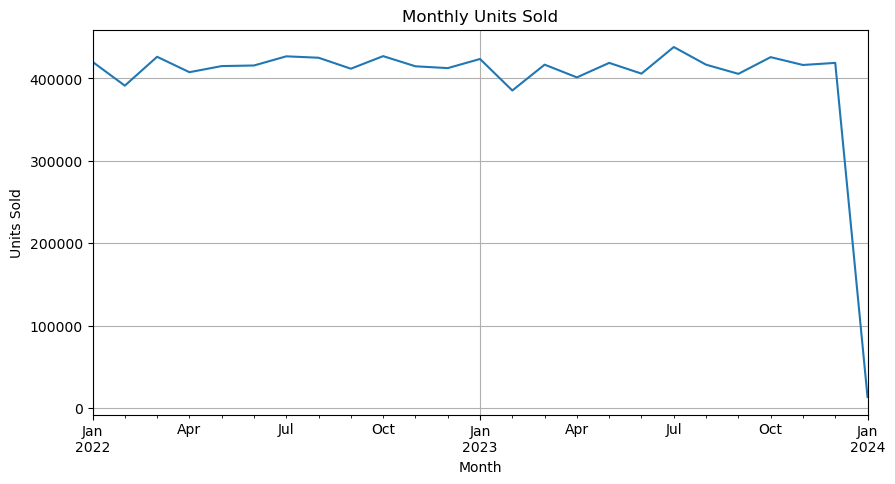

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

monthly_sales.plot(kind="line")

plt.title("Monthly Units Sold")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.grid(True)
plt.show()

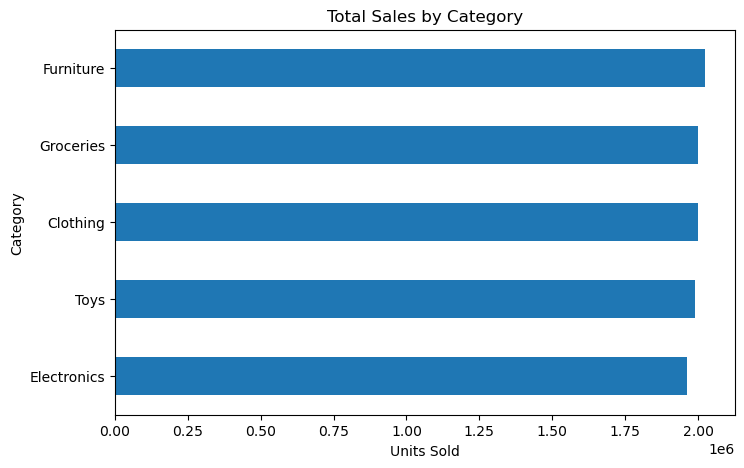

In [72]:
plt.figure(figsize=(8, 5))

category_sales.sort_values().plot(kind="barh")

plt.title("Total Sales by Category")
plt.xlabel("Units Sold")
plt.ylabel("Category")
plt.show()

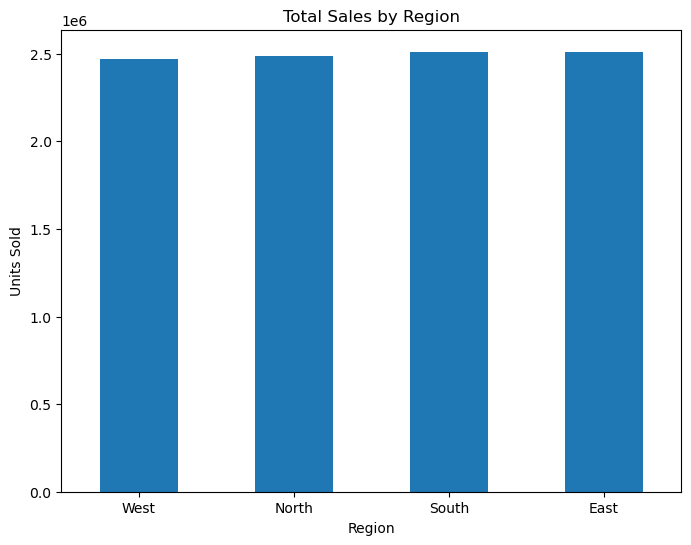

In [71]:
plt.figure(figsize=(8, 6))

region_sales.sort_values().plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Units Sold")
plt.xticks(rotation=0)
plt.show()

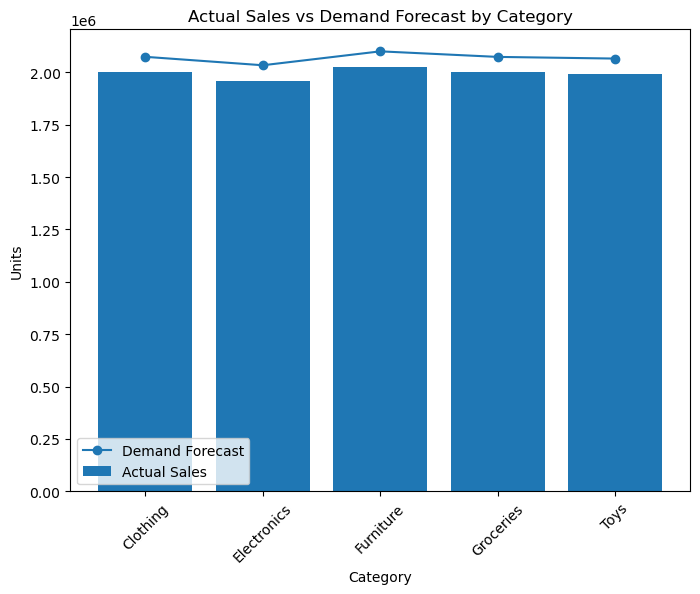

In [75]:
plt.figure(figsize=(8, 6))

plt.bar(
    category_forecast.index,
    category_forecast["Actual_Sales"],
    label="Actual Sales"
)

plt.plot(
    category_forecast.index,
    category_forecast["Forecast"],
    marker="o",
    label="Demand Forecast"
)

plt.title("Actual Sales vs Demand Forecast by Category")
plt.xlabel("Category")
plt.ylabel("Units")
plt.legend()
plt.xticks(rotation=45)
plt.show()

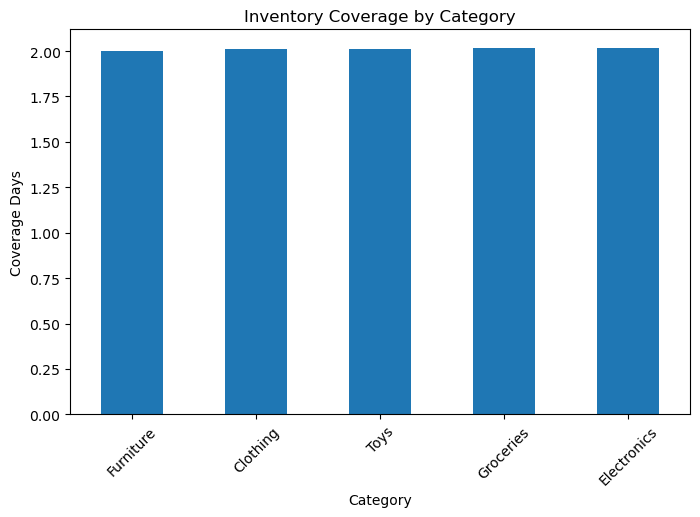

In [76]:
plt.figure(figsize=(8, 5))

category_analysis["Inventory_Coverage_Days"].sort_values().plot(
    kind="bar"
)

plt.title("Inventory Coverage by Category")
plt.xlabel("Category")
plt.ylabel("Coverage Days")
plt.xticks(rotation=45)
plt.show()

In [78]:
clean_df.to_csv("Retail_Inventory_Cleaned.csv", index=False)

print("Cleaned dataset exported successfully.")
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))

Cleaned dataset exported successfully.
Rows: 73100
Columns: 15
